In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Impostiamo lo stile dei grafici
sns.set_theme(style="whitegrid")

# Percorso relativo per tornare indietro da 'notebooks' e entrare in 'data/processed'
# Se ti dà errore, controlla il nome esatto del file nella cartella data
file_path = '../data/processed/KICKSTARTER_CLEAN_BASE.csv'

print(f"Caricamento dati da: {file_path}...")
df = pd.read_csv(file_path, low_memory=False)

# Convertiamo subito le date (che nel CSV sono tornate stringhe)
if 'launched_at' in df.columns:
    df['launched_at'] = pd.to_datetime(df['launched_at'], unit='s')
if 'deadline' in df.columns:
    df['deadline'] = pd.to_datetime(df['deadline'], unit='s')

print(f"Dataset caricato: {df.shape[0]} righe, {df.shape[1]} colonne.")
df.head(3)

Caricamento dati da: ../data/processed/KICKSTARTER_CLEAN_BASE.csv...
Dataset caricato: 188954 righe, 43 colonne.


,backers_count,blurb,category,converted_pledged_amount,country,country_displayable_name,created_at,creator,currency,currency_symbol,...,staff_pick,state,state_changed_at,static_usd_rate,urls,usd_exchange_rate,usd_pledged,usd_type,video,sort_date
0,130,A heroine's first day on the job uncovers a te...,"{""id"":250,""name"":""Comic Books"",""analytics_name...",2869,US,the United States,1680453340,"{""id"":406452038,""name"":""Victor. E Kizenko"",""is...",USD,$,...,False,successful,1730645950,1.0,"{""web"":{""project"":""https://www.kickstarter.com...",1.0,2869.0,domestic,"{""id"":1300562,""status"":""successful"",""hls"":""htt...",1730645950
1,4,Raising money to help my grandmother recover f...,"{""id"":44,""name"":""World Music"",""analytics_name""...",62,US,the United States,1476879198,"{""id"":1501687606,""name"":""Devan Porter"",""is_reg...",USD,$,...,False,failed,1479479560,1.0,"{""web"":{""project"":""https://www.kickstarter.com...",1.0,62.0,domestic,NaN,1479479560
2,81,"The cute, soft, and huggable plushies are read...","{""id"":396,""name"":""Toys"",""analytics_name"":""Toys...",4815,US,the United States,1712605555,"{""id"":687343559,""name"":""StrawBunnyCake"",""slug""...",USD,$,...,False,successful,1719595863,1.0,"{""web"":{""project"":""https://www.kickstarter.com...",1.0,4815.0,domestic,NaN,1719595863


state
successful    117688
failed         71266
Name: count, dtype: int64


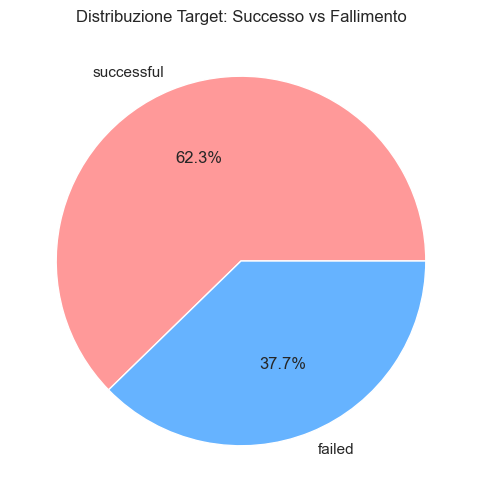

In [10]:
# Contiamo successi e fallimenti
target_counts = df['state'].value_counts()
print(target_counts)

plt.figure(figsize=(6, 6))
plt.pie(target_counts, labels=target_counts.index, autopct='%1.1f%%', colors=['#ff9999','#66b3ff'])
plt.title('Distribuzione Target: Successo vs Fallimento')
plt.show()

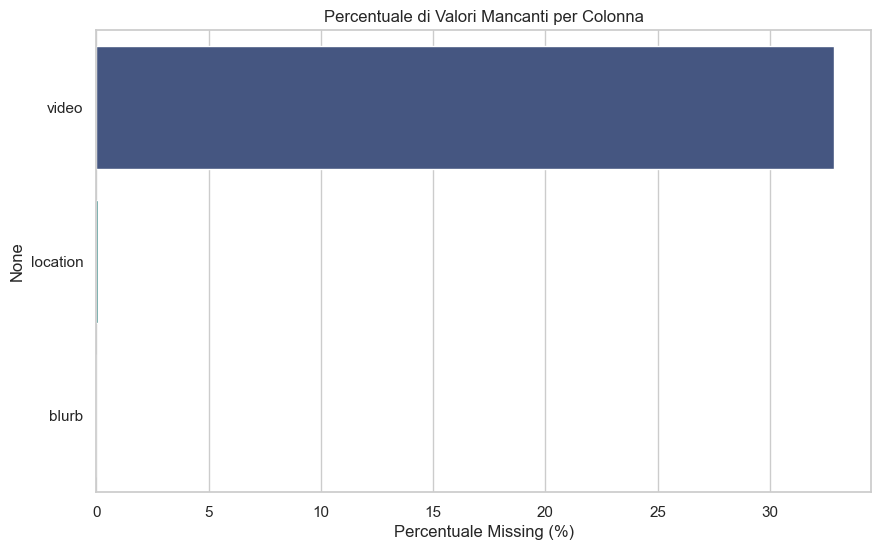

Percentuali valori mancanti:
video       32.868317
location     0.078326
blurb        0.001588
dtype: float64


In [11]:
# Calcoliamo la % di mancanti
missing = df.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)

if not missing.empty:
    missing_pct = (missing / len(df)) * 100

    plt.figure(figsize=(10, 6))
    # CORREZIONE: Aggiunto hue=missing_pct.index e legend=False
    sns.barplot(x=missing_pct.values, y=missing_pct.index, hue=missing_pct.index, palette="viridis", legend=False)

    plt.title('Percentuale di Valori Mancanti per Colonna')
    plt.xlabel('Percentuale Missing (%)')
    plt.show()

    # Stampiamo i valori esatti
    print("Percentuali valori mancanti:")
    print(missing_pct)
else:
    print("Nessun valore mancante trovato! Il dataset è completo.")

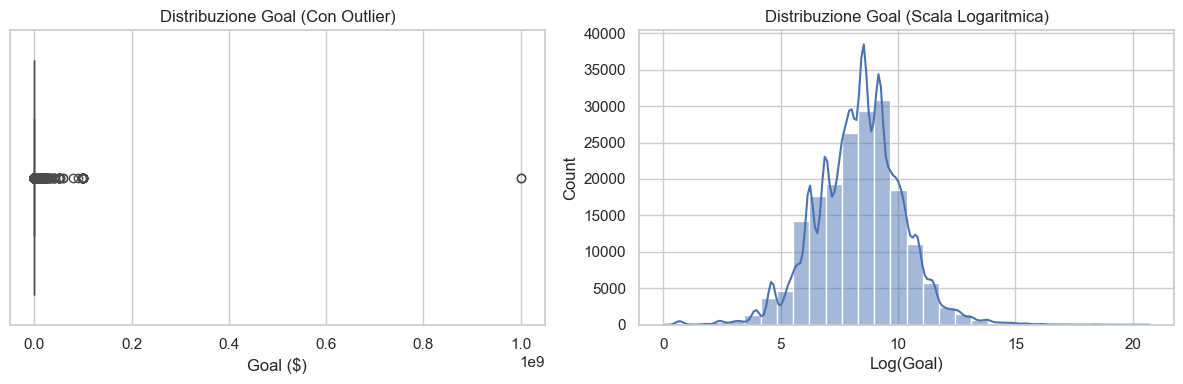

Goal Massimo: 1000000000.0
Goal Mediano: 5000.0


In [12]:
# Convertiamo il goal in numerico se non lo è
df['goal'] = pd.to_numeric(df['goal'], errors='coerce')

# Grafico 1: Boxplot con gli Outlier
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
sns.boxplot(x=df['goal'])
plt.title('Distribuzione Goal (Con Outlier)')
plt.xlabel('Goal ($)')

# Grafico 2: Distribuzione Logaritmica (Soluzione)
# Applichiamo il logaritmo per vedere meglio la distribuzione
plt.subplot(1, 2, 2)
sns.histplot(np.log1p(df['goal']), bins=30, kde=True)
plt.title('Distribuzione Goal (Scala Logaritmica)')
plt.xlabel('Log(Goal)')

plt.tight_layout()
plt.show()

print(f"Goal Massimo: {df['goal'].max()}")
print(f"Goal Mediano: {df['goal'].median()}")

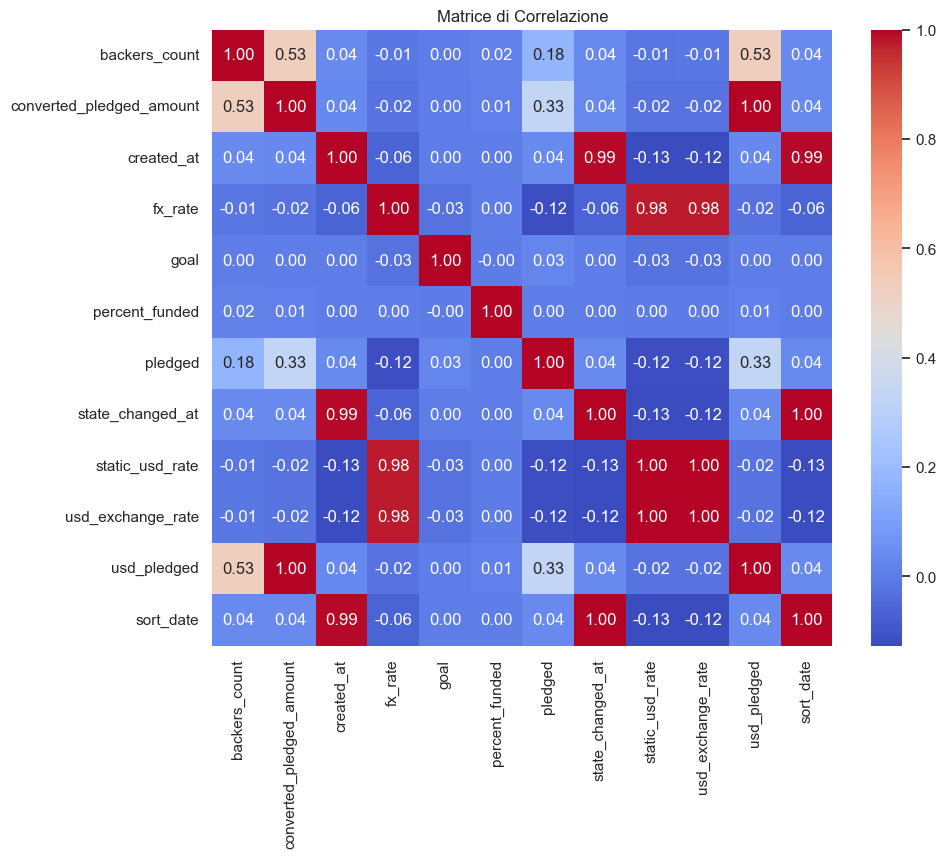

In [13]:
# Selezioniamo solo colonne numeriche
numeric_cols = df.select_dtypes(include=[np.number]).columns
# Rimuoviamo colonne inutili tipo ID
cols_corr = [c for c in numeric_cols if c not in ['id', 'creator_id']]

plt.figure(figsize=(10, 8))
sns.heatmap(df[cols_corr].corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Matrice di Correlazione')
plt.show()

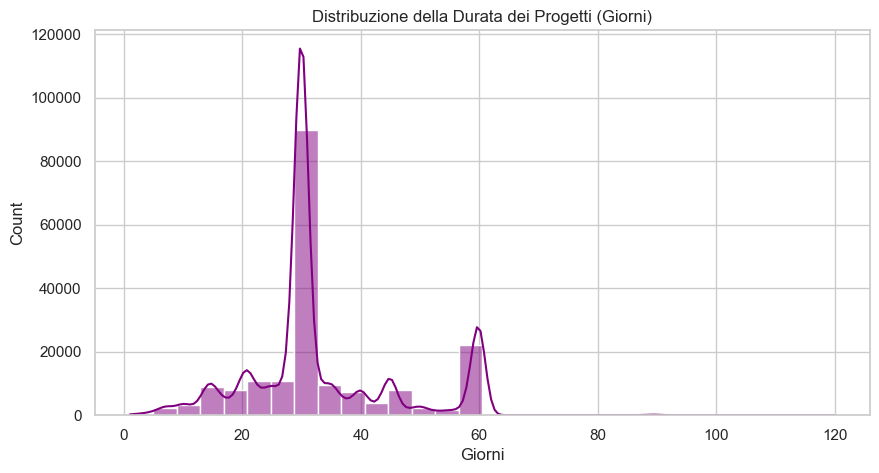

Durata media: 33.0 giorni
Durata mediana: 30.0 giorni


In [14]:
import json
import ast

# 1. Calcolo la durata in giorni (se non l'hai già fatto)
# Assicuriamoci che siano datetime
df['launched_at'] = pd.to_datetime(df['launched_at'], unit='s')
df['deadline'] = pd.to_datetime(df['deadline'], unit='s')
df['duration_days'] = (df['deadline'] - df['launched_at']).dt.days

# 2. Istogramma della durata
plt.figure(figsize=(10, 5))
sns.histplot(df['duration_days'], bins=30, kde=True, color='purple')
plt.title('Distribuzione della Durata dei Progetti (Giorni)')
plt.xlabel('Giorni')
plt.show()

# Statistiche veloci
print(f"Durata media: {df['duration_days'].mean():.1f} giorni")
print(f"Durata mediana: {df['duration_days'].median():.1f} giorni")

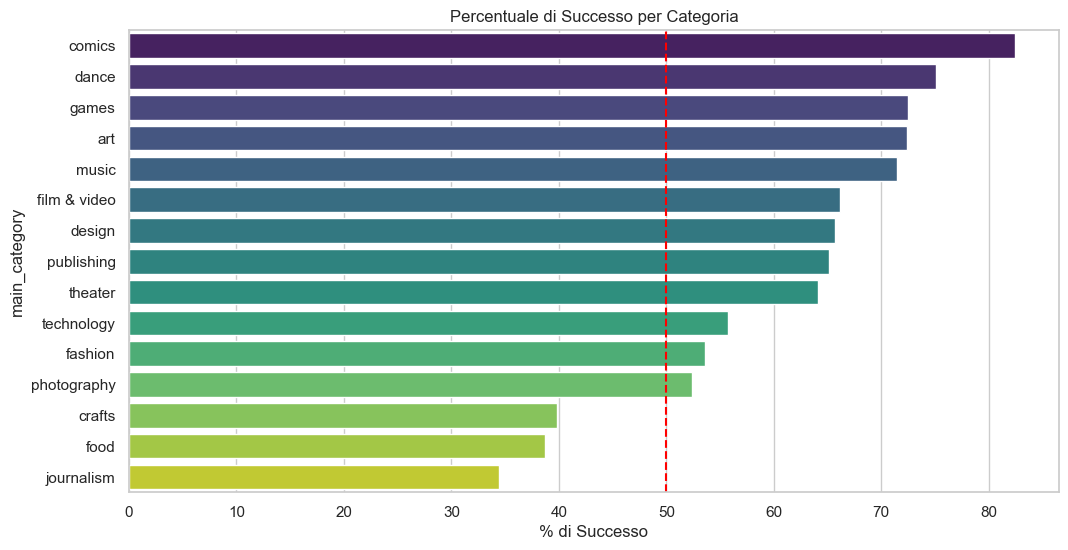

In [15]:
# Funzione per estrarre la categoria principale (es. da "technology/web" prende "technology")
def estrai_categoria(x):
    try:
        # Se è una stringa, prova a convertirla in dizionario
        if isinstance(x, str):
            d = json.loads(x)
            slug = d.get('slug', '')
            return slug.split('/')[0] # Prende la parte prima dello slash
        return "Unknown"
    except:
        return "Error"

# Applichiamo la funzione
df['main_category'] = df['category'].apply(estrai_categoria)

# Calcoliamo la % di successo per categoria
cat_success = df.groupby('main_category')['state'].apply(lambda x: (x == 'successful').mean() * 100).sort_values(ascending=False)

# Grafico
plt.figure(figsize=(12, 6))
sns.barplot(x=cat_success.values, y=cat_success.index, hue=cat_success.index, palette="viridis", legend=False)
plt.title('Percentuale di Successo per Categoria')
plt.xlabel('% di Successo')
plt.axvline(50, color='red', linestyle='--') # Linea del 50%
plt.show()

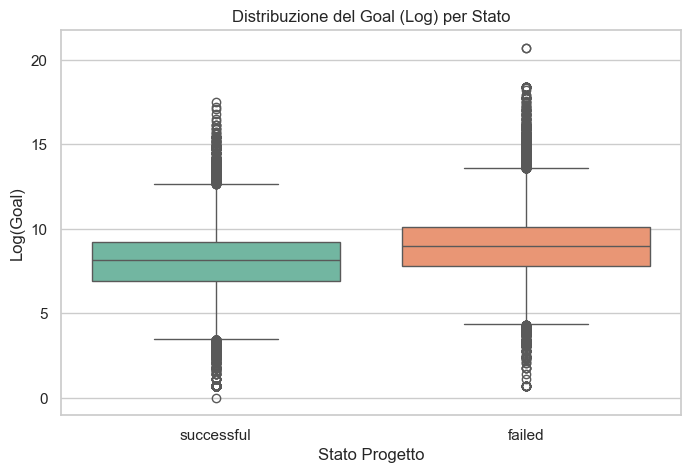

In [16]:
# Usiamo il Log del Goal per visualizzare meglio (altrimenti gli outlier schiacciano tutto)
df['log_goal'] = np.log1p(df['goal'])

plt.figure(figsize=(8, 5))
sns.boxplot(x='state', y='log_goal', data=df, hue='state', palette="Set2", legend=False)
plt.title('Distribuzione del Goal (Log) per Stato')
plt.xlabel('Stato Progetto')
plt.ylabel('Log(Goal)')
plt.show()

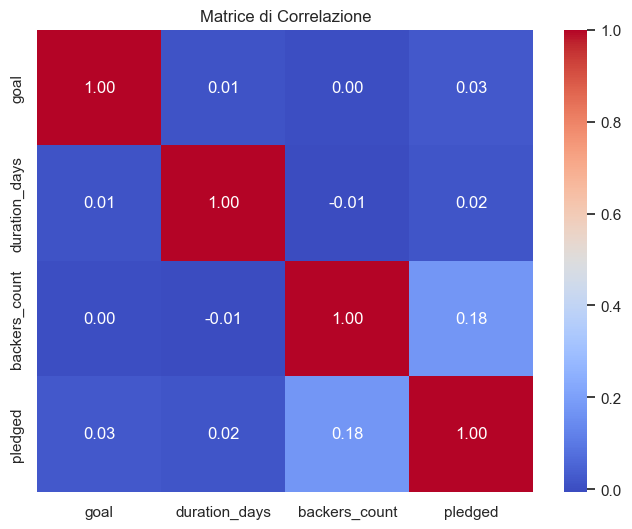

In [17]:
# Selezioniamo solo le colonne numeriche utili
cols_for_corr = ['goal', 'duration_days', 'backers_count', 'pledged']
# Nota: backers e pledged sono "spoiler", ma nell'EDA si possono guardare per capire le relazioni

# Calcolo correlazione
corr = df[cols_for_corr].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Matrice di Correlazione')
plt.show()